In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

from sklearn.metrics import mean_squared_error

In [2]:
DATA_ROOT = '../../../data'

In [3]:
def create_pearsons_violin(results_df, y_col, title, file_title, figure_root = './figures', **kwargs):
    '''
    Taking a results df with two columns ['pearsons', 'dataset'] 
    Plots the pearsons values by dataset of origin as violin plots and saves figure with specified file_title at figure_root

    Parameters
    ---------------
    results_df : pandas dataframe
        dataframe containg the results to plot. Must contain a categorical column called dataset to serve as x axis categories
    y_col : string
        name of column in results df with statistic to make violin plot for 
    title : string
        title to display on plot
    file_title : string
        filename of saved figure
    figure_root : string
        path to directory in which to save the figure

    Returns
    --------------
    None
        Saves figure to desired location
    '''

    #store all plot formating arguments in dictionary - kwargs can then override
    plot_defaults = {'ylim':(-1, 1),
                     'palette':'viridis'}

    plot_kwargs = {**plot_defaults, **kwargs}

    #violin_plot_arguments = list(inspect.signature(sns.violinplot).parameters.keys())

    savepath = f'{figure_root}/{file_title}'

    fig, ax = plt.subplots()
    
    ax = sns.violinplot(data = results_df, x = 'dataset', y= y_col, hue = 'dataset', palette=plot_kwargs['palette'])

    if y_col == 'pearsons':
        ax.set_ylabel('Pearsons R', fontsize = 15)
    elif y_col == 'spearmans':
        ax.set_ylabel('Spearmans Rank', fontsize = 15)
    ax.set_xlabel('Dataset', fontsize = 15)
   
    plt.ylim(plot_kwargs['ylim'])
    fig.suptitle(title, fontsize = 20)
    plt.savefig(savepath, dpi = 300, bbox_inches = 'tight')

In [4]:
results_df = pd.read_csv(f'{DATA_ROOT}/female_male_PCC.csv', index_col = 0)
results_df.columns = ['Female', 'Male']

In [7]:
results_df.Female.describe()

count    15140.000000
mean         0.691805
std          0.248439
min         -0.203594
25%          0.562434
50%          0.789463
75%          0.883706
max          0.966268
Name: Female, dtype: float64

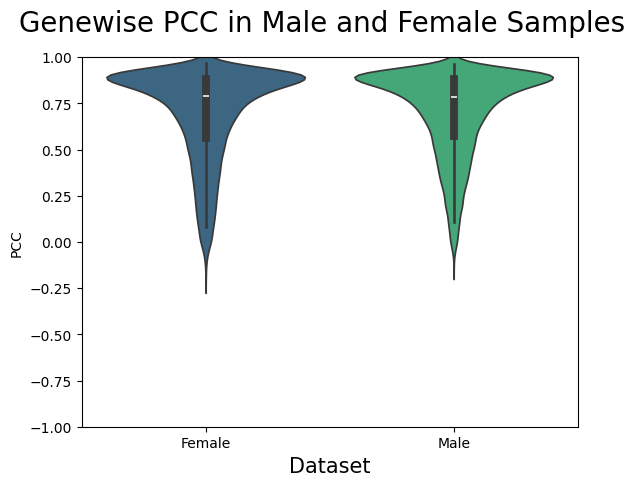

In [6]:
results_df_to_plot = results_df.melt()
results_df_to_plot.columns = ['dataset', 'PCC']
create_pearsons_violin(results_df_to_plot, y_col = 'PCC', title = 'Genewise PCC in Male and Female Samples', file_title = 'female_male_violins')

# Calculate correlations from files

In [6]:
female_actual = pd.read_csv(f'{DATA_ROOT}/female_actual_gene_expressions.csv', index_col = 0)
female_predicted = pd.read_csv(f'{DATA_ROOT}/female_predicted_gene_expressions.csv', index_col = 0)

male_actual = pd.read_csv(f'{DATA_ROOT}/male_actual_gene_expressions.csv', index_col = 0)
male_predicted = pd.read_csv(f'{DATA_ROOT}/male_predicted_gene_expressions.csv', index_col = 0)

In [8]:
#fill NAs with zeros - don't know why this is happening
female_actual = female_actual.fillna(0)
female_predicted = female_predicted.fillna(0)
male_actual = male_actual.fillna(0)
male_predicted = male_predicted.fillna(0)

In [ ]:
def get_correlations_df(df1, df2, dataset_label, rowise = True):
    '''
    Uses get_correlations to calculate the row or columnwise perasons correlations between two dataframes with the same dimensions
    
    Returns the result as a df suitable for later concatenating and use with seaborn violin plots where the columns are ['value', 'dataset']
    The resulting dataframe has dimensions (n, 2) where n is the number of rows in df1 
    '''

    #initialise df
    results_df = pd.DataFrame(columns = ['pearsons', 'spearmans','MSE', 'dataset'])
    #add pearsons correlation between df1, df2 to the pearsons column

    if rowise == False:
        df1 = df1.T
        df2 = df2.T

    for i in range(0, df1.shape[0]):
        df1_row = np.asarray(df1.iloc[i, :])
        df2_row = np.asarray(df2.iloc[i, :])

        results_df.loc[i, "pearsons"] = scipy.stats.pearsonr(np.asarray(df1.iloc[i, :]), np.asarray(df2.iloc[i, :])).statistic
        results_df.loc[i, 'spearmans'] = scipy.stats.spearmanr(df1.iloc[i, :], df2.iloc[i, :]).statistic
        #results_df.loc[i, 'MSE'] = mean_squared_error(df1.iloc[i, :], df2.iloc[i, :])
        results_df.loc[i, "dataset"] = dataset_label



    return(results_df)



In [9]:
print('Calculating Genewise Correlations')
genewise_df_list = []
genewise_df_list.append(get_correlations_df(female_actual, female_predicted, dataset_label='Female', rowise = False))
genewise_df_list.append(get_correlations_df(male_actual, male_predicted, dataset_label='Male', rowise = False))

genewise_correlations = pd.concat(genewise_df_list, ignore_index=True)


Calculating Genewise Correlations


/tmp/ipykernel_2329056/1961240770.py:21: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  results_df.loc[i, "pearsons"] = scipy.stats.pearsonr(np.asarray(df1.iloc[i, :]), np.asarray(df2.iloc[i, :])).statistic
/tmp/ipykernel_2329056/1961240770.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  results_df.loc[i, 'spearmans'] = scipy.stats.spearmanr(df1.iloc[i, :], df2.iloc[i, :]).statistic
/tmp/ipykernel_2329056/1961240770.py:21: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  results_df.loc[i, "pearsons"] = scipy.stats.pearsonr(np.asarray(df1.iloc[i, :]), np.asarray(df2.iloc[i, :])).statistic
/tmp/ipykernel_2329056/1961240770.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  results_df.loc[i, 'spearmans'] = scipy.stats.spearmanr(df1.iloc[i, :], df2.iloc[i, :]).statistic
/tmp/ipykernel_23290

In [10]:
print('Calculating Samplewise Correlations')
samplewise_df_list = []
samplewise_df_list.append(get_correlations_df(female_actual, female_predicted, dataset_label='Female', rowise = True))
samplewise_df_list.append(get_correlations_df(male_actual, male_predicted, dataset_label='Male', rowise = True))

samplewise_correlations = pd.concat(samplewise_df_list, ignore_index=True)

Calculating Samplewise Correlations


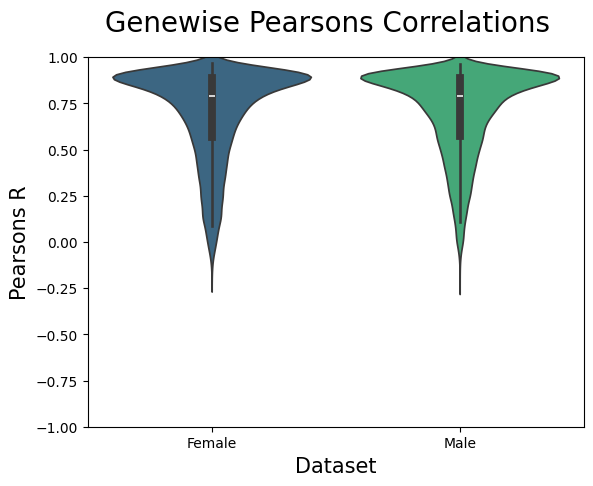

In [11]:
create_pearsons_violin(results_df=genewise_correlations, y_col='pearsons', title = f'Genewise Pearsons Correlations', file_title = f'MF_external_genewise_from_file', figure_root=f'./figures')

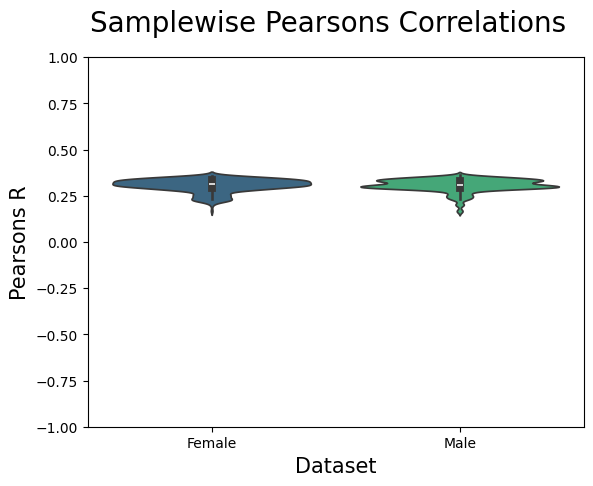

In [12]:
create_pearsons_violin(results_df=samplewise_correlations, y_col='pearsons', title = f'Samplewise Pearsons Correlations', file_title = f'MF_external_samplewise_from_file', figure_root=f'./figures')

In [13]:
results_df

,Female,Male
A2M,0.802690,0.793515
A2ML1,0.304064,0.305050
A4GALT,0.589042,0.515230
AAAS,0.898726,0.914515
AACS,0.846126,0.805570
...,...,...
ZYG11A,0.653688,0.616068
ZYG11B,0.836578,0.860950
ZYX,0.720547,0.683728
ZZEF1,0.917432,0.915107
